Q3.
b)
You are given a bank dataset containing the following features:

DD (Demand Drafts),
Withdrawals,
Deposits,
Branch Area (in sq. ft.),
Average Daily Walk-ins

Perform K-Means clustering on the given dataset by selecting relevant features, appropriately preprocessing the data (including handling missing values and scaling), determining the optimal number of clusters using the Elbow Method, and then applying the K-Means clustering algorithm based on the identified number of clusters.

**K-Means Implementation in Python**

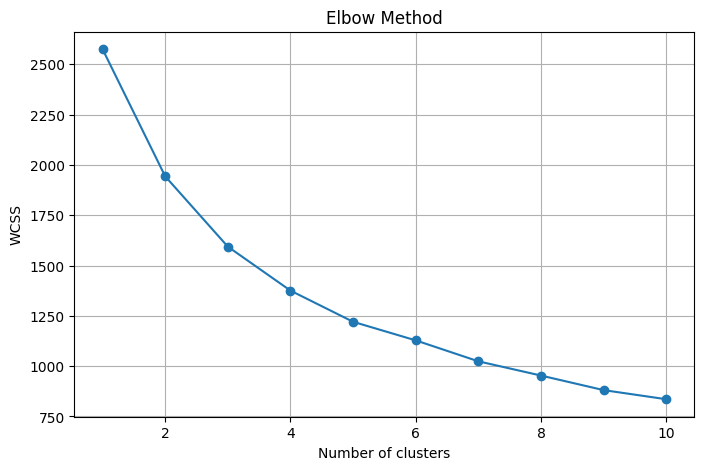

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('bank.csv')

# Drop the 'Bank' column (ID, not useful for clustering)
df_features = df.drop('Bank', axis=1)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


   Bank   DD  Withdrawals  Deposits  Branch Area in sqft  avg daily walkins  \
0     1  227          147       111                 2460                639   
1     2  123           86        65                 3510                436   
2     3  306          149        76                 2570                669   
3     4  251          112       129                 3650                623   
4     5  174          135       128                 3400                579   

   Cluster  
0        0  
1        1  
2        0  
3        2  
4        1  


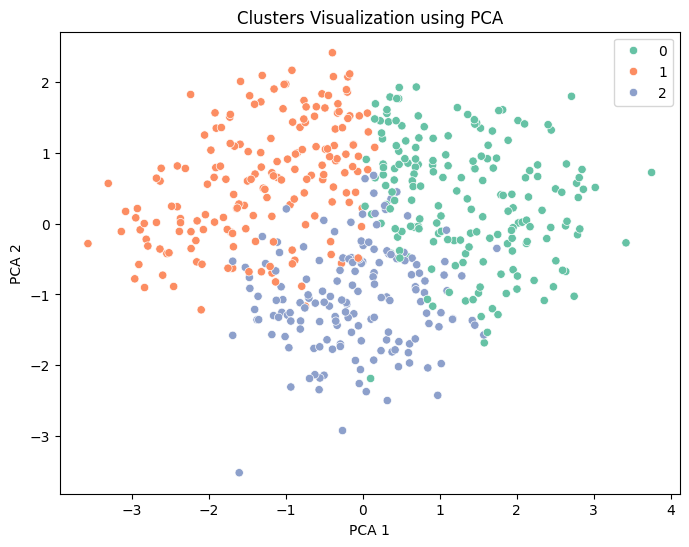

In [3]:
# Apply KMeans with the chosen number of clusters
optimal_k = 3  # change this based on your elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to the original dataframe
df['Cluster'] = clusters

# View the first few rows with cluster labels
print(df.head())

# Optional: visualize clusters using first two PCA components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette='Set2')
plt.title('Clusters Visualization using PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


**Apriori Market Basket Analysis in Python**

Q4.
b)
You are provided with an online retail dataset that  contains transaction-level
data, including InvoiceNo, Description, Quantity, and InvoiceDate.
Using the Apriori algorithm, perform a market basket analysis on this dataset under the following constraints:
•	Minimum Support: 0.2
•	Minimum Confidence: 0.8
•	Minimum Lift: 6.0


In [7]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load the dataset
df = pd.read_excel('online_retail_qp.xlsx')

# Remove rows with negative quantity
df = df[df['Quantity'] > 0]

# Group transactions by InvoiceNo and list product Descriptions
basket = df.groupby('InvoiceNo')['Description'].apply(list)

# Convert to list of lists
transactions = basket.tolist()

# One-hot encode the transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True)

# Extract association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=6.0)

# Filter rules by confidence
rules = rules[rules['confidence'] >= 0.8]

# Display resulting rules
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


No association rules were discovered.

Interpretation:
This means there were no strong patterns that met all criteria. This could be due to:

A relatively small number of transactions.

A high number of unique items with low co-occurrence.

Strict thresholds that reduce rule discovery.

**This was an alternate code with the updated value**
•	Minimum Support: 0.1
•	Minimum Confidence: 0.7
•	Minimum Lift: 3.0

I have written this code, because I received Empty Dataframe if I pass the value which was given in Question Paper.

In [10]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load dataset
df = pd.read_excel('online_retail_qp.xlsx')

# Filter out negative or zero quantities
df = df[df['Quantity'] > 0]

# Group items by InvoiceNo to form transactions
basket = df.groupby('InvoiceNo')['Description'].apply(list)

# Convert to list of transactions
transactions = basket.tolist()

# One-hot encode the transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Filter rules for higher lift
rules = rules[rules['lift'] >= 3.0]

# Display resulting rules
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


                              antecedents  \
0                (6 RIBBONS RUSTIC CHARM)   
1                (JAM MAKING SET PRINTED)   
2                (6 RIBBONS RUSTIC CHARM)   
3                (6 RIBBONS RUSTIC CHARM)   
4                (6 RIBBONS RUSTIC CHARM)   
...                                   ...   
323355  (DINOSAUR LUNCH BOX WITH CUTLERY)   
323356               (PINK POLKADOT BOWL)   
323357  (CHILDRENS CUTLERY POLKADOT PINK)   
323358             (RED RETROSPOT PLATE )   
323359             (BLUE POLKADOT PLATE )   

                                              consequents   support  \
0                                  (DOLLY GIRL LUNCH BOX)  0.117647   
1                                (6 RIBBONS RUSTIC CHARM)  0.117647   
2                                (JAM MAKING SET PRINTED)  0.117647   
3                             (RED RETROSPOT SHOPPER BAG)  0.117647   
4                            (SET OF 3 REGENCY CAKE TINS)  0.117647   
...                              